# Merge pkl trajectories

Simple version: load several `.pkl` files, keep only common keys, resample to one FPS, pad/trim to one length, then save.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import tools


# [pkl path, merge ratio]
# Set ratio to None if you want to use all trajectories from all files.
FILES = [
    [Path("data/umi_cup_in_wild.pkl"), 1],
    [Path("data/pushing.pkl"), 1],
    [Path("data/tossing.pkl"), 1],
]

SAVE_PATH = Path("data/umi_merged_traj.pkl")

# If different files have different fps, resample all trajectories to this fps.
TARGET_FPS = 200

# "max" keeps all trajectory duration and pads shorter ones.
# You can also set an int, for example TARGET_LEN = 2000.
TARGET_LEN = "max"

RANDOM_SEED = 0

In [2]:
# Resample / pad functions

def get_signal_len(traj, keys):
    return min(len(traj[k]) for k in keys if k != "t")


def get_signal_t(traj, signal_len):
    t = np.asarray(traj["t"], dtype=float)

    if len(t) == signal_len:
        signal_t = t
    elif len(t) == signal_len + 1:
        signal_t = t[:-1]
    else:
        signal_t = np.linspace(t[0], t[-1], signal_len, endpoint=False)

    return signal_t - signal_t[0]


def interp_value(old_t, value, new_t):
    value = np.asarray(value, dtype=float)[: len(old_t)]

    if value.ndim == 1:
        return np.interp(new_t, old_t, value)

    flat_value = value.reshape(value.shape[0], -1)
    new_value = np.zeros((len(new_t), flat_value.shape[1]))
    for i in range(flat_value.shape[1]):
        new_value[:, i] = np.interp(new_t, old_t, flat_value[:, i])

    return new_value.reshape((len(new_t),) + value.shape[1:])


def resize_traj(traj, keys, target_fps):
    signal_len = get_signal_len(traj, keys)
    old_t = get_signal_t(traj, signal_len)
    duration = traj["t"][-1] - traj["t"][0]

    new_len = int(round(duration * target_fps))
    new_t = np.arange(new_len) / target_fps

    new_traj = {}
    for key in keys:
        if key == "t":
            new_traj[key] = new_t
        else:
            new_traj[key] = interp_value(old_t, traj[key], new_t)

    # pushing.pkl has gripper_width shape (T, 3), tossing.pkl has shape (T,).
    # Use one scalar gripper width per frame so merged shapes are consistent.
    if "gripper_width" in new_traj and new_traj["gripper_width"].ndim > 1:
        new_traj["gripper_width"] = new_traj["gripper_width"].mean(axis=1)

    return new_traj


def sample_by_ratio(data_list, ratios=None, seed=0):
    if ratios is None:
        return data_list

    if len(ratios) != len(data_list):
        raise ValueError("ratio count must match file count")

    ratios = np.asarray(ratios, dtype=int)
    if np.any(ratios <= 0):
        raise ValueError("ratios must be positive integers")

    rng = np.random.default_rng(seed)
    base_count = min(len(data) // ratio for data, ratio in zip(data_list, ratios))
    sample_counts = ratios * base_count

    sampled_data_list = []
    for data, sample_count in zip(data_list, sample_counts):
        indices = rng.choice(len(data), size=sample_count, replace=False)
        sampled_data_list.append([data[i] for i in indices])

    return sampled_data_list


def pad_or_trim(traj, target_len, target_fps):
    new_traj = {}
    for key, value in traj.items():
        value = np.asarray(value)

        if key == "t":
            new_traj[key] = np.arange(target_len) / target_fps
        elif len(value) >= target_len:
            new_traj[key] = value[:target_len]
        else:
            pad_len = target_len - len(value)
            pad = np.repeat(value[-1:], pad_len, axis=0)
            new_traj[key] = np.concatenate([value, pad], axis=0)

    return new_traj

In [3]:
# Merge

PKL_FILES = [file[0] for file in FILES]
RATIOS = [file[1] for file in FILES]
RATIOS = None if any(ratio is None for ratio in RATIOS) else RATIOS

data_list = [tools.load_pkl(path) for path in PKL_FILES]
keys = tools.get_keys(data_list)
sampled_data_list = sample_by_ratio(data_list, RATIOS, RANDOM_SEED)

print("Input files:")
for path, data, sampled_data in zip(PKL_FILES, data_list, sampled_data_list):
    print(path, "num_traj =", len(data), "sampled =", len(sampled_data), "fps =", tools.get_fps(data), "dt =", tools.get_dt(data))

print("\nMerged keys:", keys)

merged = []
for data in sampled_data_list:
    for traj in data:
        merged.append(resize_traj(traj, keys, TARGET_FPS))

lengths = [len(traj["t"]) for traj in merged]
target_len = max(lengths) if TARGET_LEN == "max" else int(TARGET_LEN)
merged = [pad_or_trim(traj, target_len, TARGET_FPS) for traj in merged]

tools.save_pkl(merged, SAVE_PATH)

print("\nSaved to:", SAVE_PATH)
print("Total trajectories:", len(merged))
print("Length before pad/trim:", min(lengths), "to", max(lengths))
print("Final length:", target_len)

Input files:
data/umi_cup_in_wild.pkl num_traj = 1090 sampled = 101 fps = 200 dt = 0.004999423390653933
data/pushing.pkl num_traj = 200 sampled = 101 fps = 200 dt = 0.004997501249375313
data/tossing.pkl num_traj = 101 sampled = 101 fps = 256 dt = 0.0038983333333333335

Merged keys: ['t', 'ee_pos', 'ee_axis_angle', 'gripper_width']

Saved to: data/umi_merged_traj.pkl
Total trajectories: 303
Length before pad/trim: 1354 to 3000
Final length: 3000


In [4]:
# Quick check

check_data = tools.load_pkl(SAVE_PATH)
print("keys:", check_data[0].keys())

for key in keys:
    shapes = sorted(set(np.asarray(traj[key]).shape for traj in check_data))
    print(key, shapes)

np.stack([traj["ee_pos"] for traj in check_data])
np.stack([traj["ee_axis_angle"] for traj in check_data])
print("stack check passed")

keys: dict_keys(['t', 'ee_pos', 'ee_axis_angle', 'gripper_width'])
t [(3000,)]
ee_pos [(3000, 3)]
ee_axis_angle [(3000, 3)]
gripper_width [(3000,)]
stack check passed


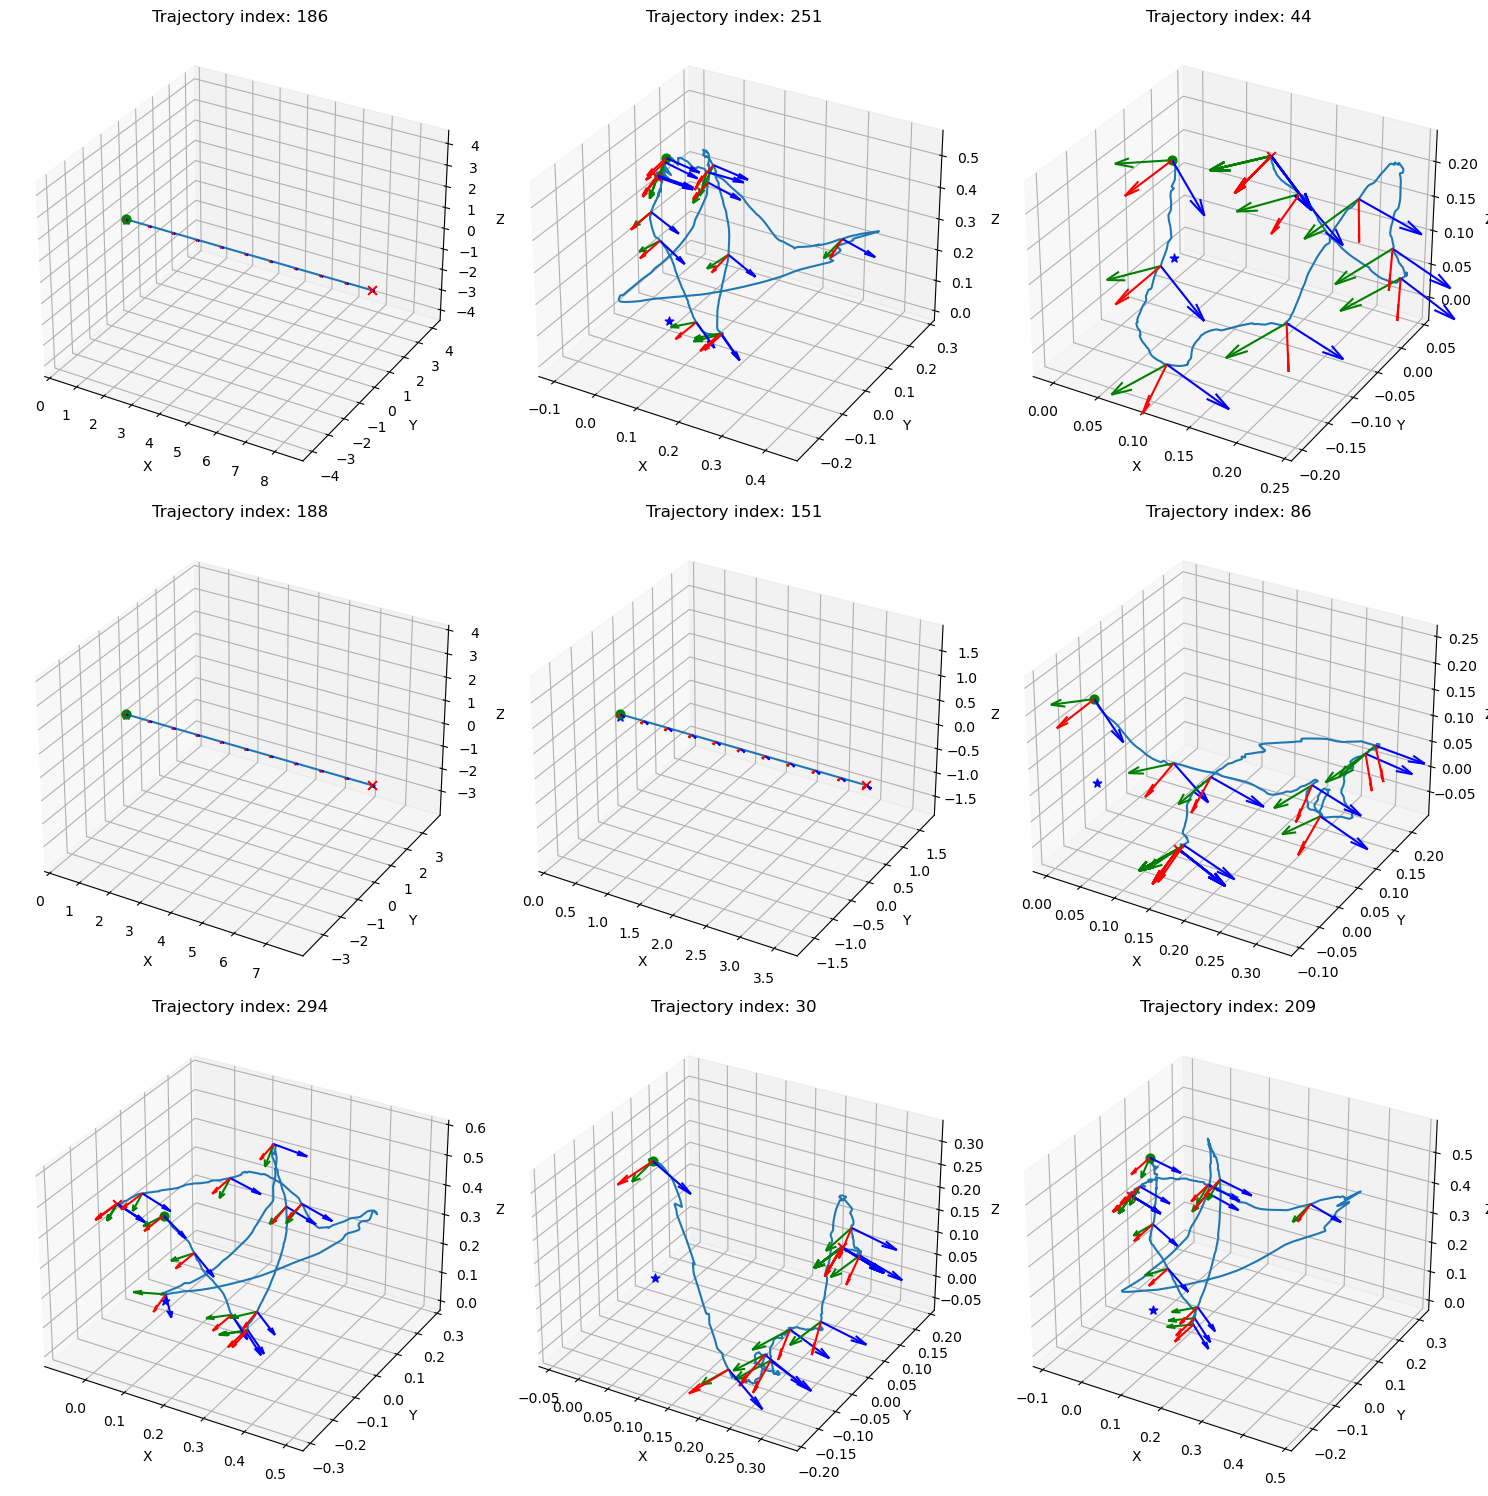

In [5]:
tools.plot_traj(merged, random=True)